# 03 — Preprocessing, feature selection and the split

Cleaning decisions with before/after counts, the stratified sample and train/test split, the leakage check, and the four-method feature selection.

**Pipeline module:** `src/preprocessing.py, src/datasets.py, src/feature_selection.py`

*Every number and figure below was produced by the pipeline in `src/`. This
notebook reads those results; it does not re-implement them.*

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import pandas as pd
from IPython.display import Image, display

TABLES = ROOT / "results" / "tables"
FIGURES = ROOT / "results" / "figures"

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 40)

def table(name, **kw):
    """Read one of the pipeline's result tables."""
    return pd.read_csv(TABLES / name, **kw)

def figure(name):
    """Display one of the pipeline's figures."""
    return Image(filename=str(FIGURES / name))

print(f"project root: {ROOT}")

project root: C:\Users\babu\OneDrive\Desktop\ML Project


## Cleaning log

Every decision is recorded with the rows it removed. The project brief requires each
cleaning decision to be documented; this table is that record.

In [2]:
log = table("cleaning_log.csv")
log[["step", "rows_before", "rows_after", "rows_removed", "percent_removed"]]

,step,rows_before,rows_after,rows_removed,percent_removed
0,fix_labels,2830743,2830743,0,0.0000
1,drop_duplicate_columns,2830743,2830743,0,0.0000
2,handle_infinities,2830743,2827876,2867,0.1013
3,drop_duplicate_rows,2827876,2498185,329691,11.6586
4,drop_constant_columns,2498185,2498185,0,0.0000
5,add_targets,2498185,2498185,0,0.0000


### The duplicates are the dangerous one

**329,691 rows — 11.66% of the dataset.** Duplicates are compared *ignoring*
`source_file`, so identical flows appearing on different capture days are caught too.

If the same row sits in both training and test data, the model has already seen the
answer. It would score near-perfectly by memorisation. PortScan lost 43% of its rows
here — a scan fires thousands of near-identical probes, so many flows genuinely are
byte-for-byte identical.

In [3]:
pairs = table("redundant_feature_pairs.csv")
print(f"{len(pairs)} feature pairs correlate above 0.95")
pairs.head(10)

23 feature pairs correlate above 0.95


,dropped,duplicate_of,correlation
0,Total Backward Packets,Total Fwd Packets,0.9997
1,Total Length of Bwd Packets,Total Fwd Packets,0.9994
2,Fwd Packet Length Std,Fwd Packet Length Max,0.9688
3,Bwd Packet Length Mean,Bwd Packet Length Max,0.9581
4,Bwd Packet Length Std,Bwd Packet Length Max,0.9824
5,Fwd IAT Total,Flow Duration,0.9984
6,Fwd IAT Max,Flow IAT Max,0.9980
7,Fwd Packets/s,Flow Packets/s,0.9808
8,Packet Length Std,Max Packet Length,0.9840
9,SYN Flag Count,Fwd PSH Flags,1.0000


## Sampling

Training six algorithms on 2.5 million rows is not practical on four CPU cores, so
the model comparison runs on a 400,040-row stratified sample and only the final model
is refit on everything.

Classes are sampled proportionally **except** where a proportional share would fall
below 50 rows. At a 16.01% rate Heartbleed's share is 1.8 rows, which would leave the
test set with none at all.

In [4]:
sampling = table("sampling_report.csv")
sampling

,class,rows_full,rows_sampled,percent_full,rule,percent_sampled
0,BENIGN,2072444,331832,82.9580,proportional,82.9497
1,DoS,193745,31022,7.7554,proportional,7.7547
2,DDoS,128014,20497,5.1243,proportional,5.1237
3,PortScan,90694,14522,3.6304,proportional,3.6301
4,Brute Force,9150,1465,0.3663,proportional,0.3662
5,Web Attack,2143,343,0.0858,proportional,0.0857
6,Bot,1948,312,0.0780,proportional,0.0780
7,Infiltration,36,36,0.0014,kept in full,0.0090
8,Heartbleed,11,11,0.0004,kept in full,0.0027


## The train/test split

80/20, stratified on the 9-class label so one split serves both experiments and their
results stay comparable.

In [5]:
balance = table("split_class_balance.csv", index_col=0)
balance

,train_%,test_%,train_n,test_n
Label_grouped,,,,
BENIGN,82.950,82.950,265465,66367
DoS,7.755,7.754,24818,6204
DDoS,5.124,5.124,16397,4100
PortScan,3.630,3.630,11618,2904
Brute Force,0.366,0.366,1172,293
Web Attack,0.086,0.086,274,69
Bot,0.078,0.077,250,62
Infiltration,0.009,0.009,29,7
Heartbleed,0.003,0.002,9,2


### Leakage check

`datasets.py` separates two things that look identical but are not:

- **True leakage** — the same features *and* the same label on both sides. The model
  can memorise the answer. Found: **0 rows**.
- **Label conflict** — the same features with *different* labels. Not leakage; the
  model gains nothing because the copies disagree. Found: **3 rows**, benign in
  training and PortScan in test.

Those three rows put a hard ceiling on achievable accuracy. Whichever label a model
predicts, it is wrong about the other copy — so a reported 100% on this dataset would
be evidence of a bug rather than a good model.

## Feature selection

Four methods, combined by average rank. Raw scores are not comparable across methods
— mutual information is in nats, forest importance sums to 1 — so each is converted
to a position before averaging.

The correlation filter is deliberately **not** a voter. It answers "is this feature a
duplicate?", not "is it useful?". In a first run it voted alongside the others and
four redundant pairs survived into the selected set, including two features
correlated at 1.0000. Used as a gate on the candidate pool instead, those slots went
to features carrying new information.

**Critically, all of this is fitted on the training split only.** Mutual information,
forest importance and RFE all learn from labels, so fitting them on the full dataset
would let test information influence which features are chosen.

In [6]:
selected = table("selected_features.csv")
print(f"{len(selected)} features selected from 70\n")
for i, name in enumerate(selected["feature"], 1):
    print(f"{i:2}. {name}")

25 features selected from 70

 1. Packet Length Variance
 2. Packet Length Mean
 3. Max Packet Length
 4. Destination Port
 5. Init_Win_bytes_backward
 6. Flow IAT Max
 7. Fwd Header Length
 8. Bwd Packets/s
 9. Bwd Header Length
10. Init_Win_bytes_forward
11. Flow IAT Std
12. Flow Bytes/s
13. Flow Packets/s
14. min_seg_size_forward
15. Fwd IAT Min
16. Bwd Packet Length Max
17. Fwd IAT Mean
18. Total Length of Fwd Packets
19. Flow IAT Mean
20. Flow IAT Min
21. Fwd IAT Std
22. Fwd Packet Length Max
23. Flow Duration
24. Bwd IAT Std
25. Bwd IAT Min


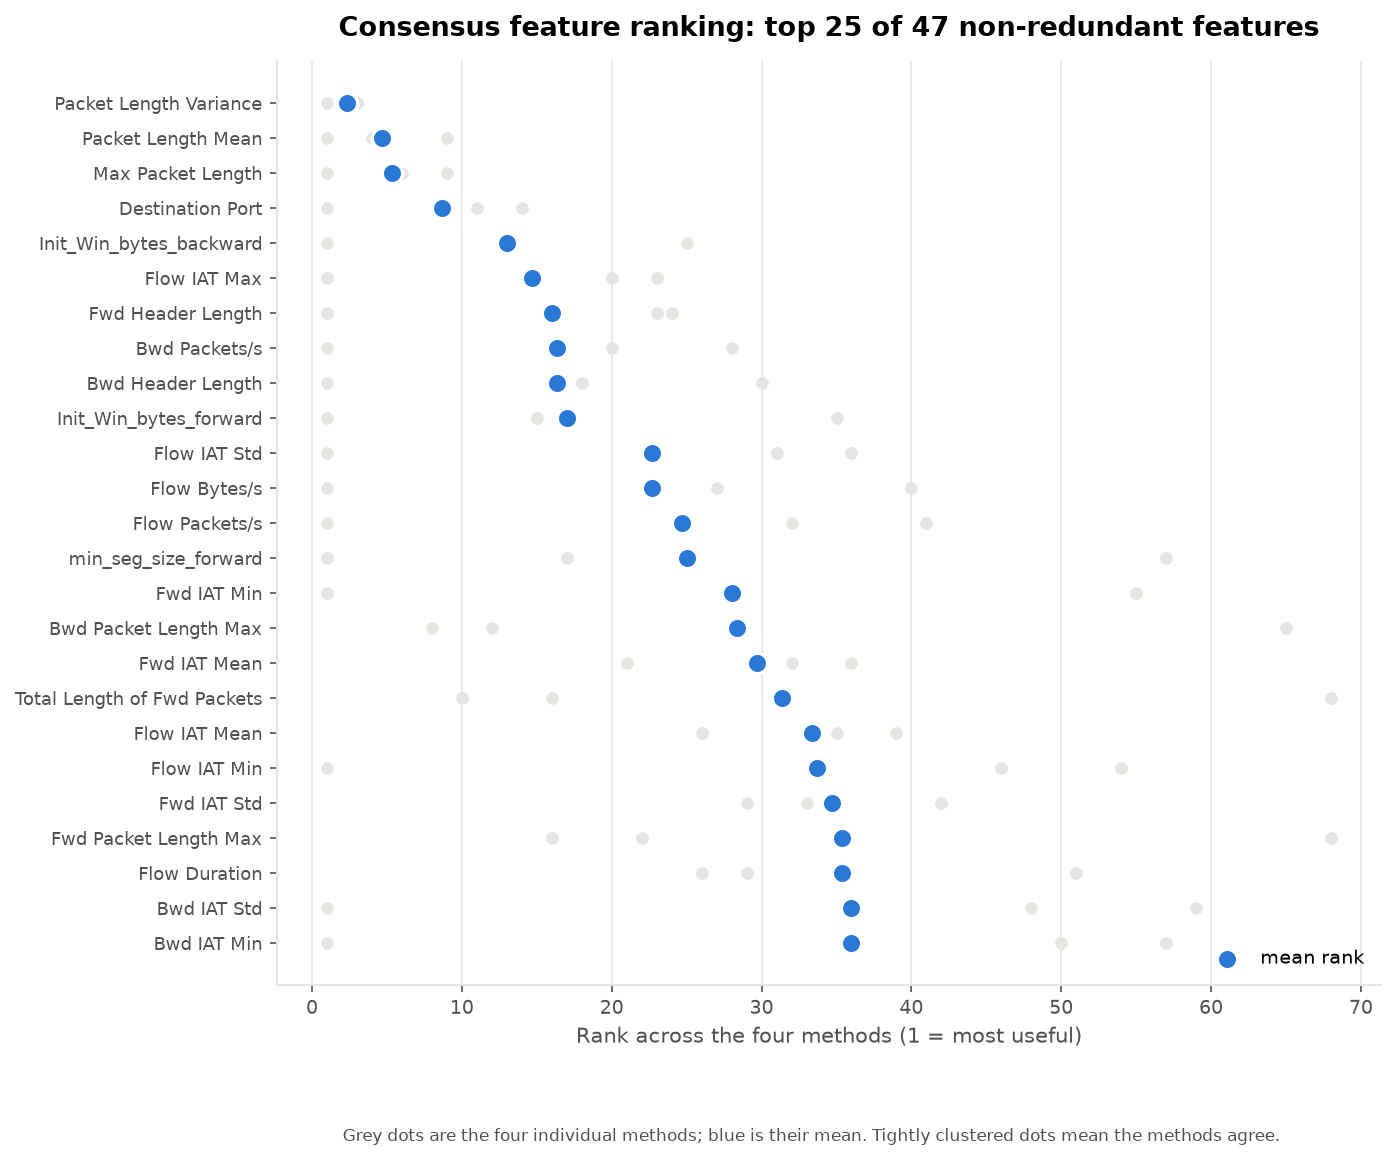

In [7]:
figure("06_feature_consensus.png")

### Does dropping 45 features cost anything?

No — it helped, on both experiments, while training faster.

In [8]:
comparison = table("feature_set_comparison.csv")
comparison

,feature_set,n_features,f1,train_seconds,target
0,all features,70,0.99600,32.2,binary
1,selected,25,0.99637,26.1,binary
2,all features,70,0.94175,36.0,multi
3,selected,25,0.95825,29.6,multi


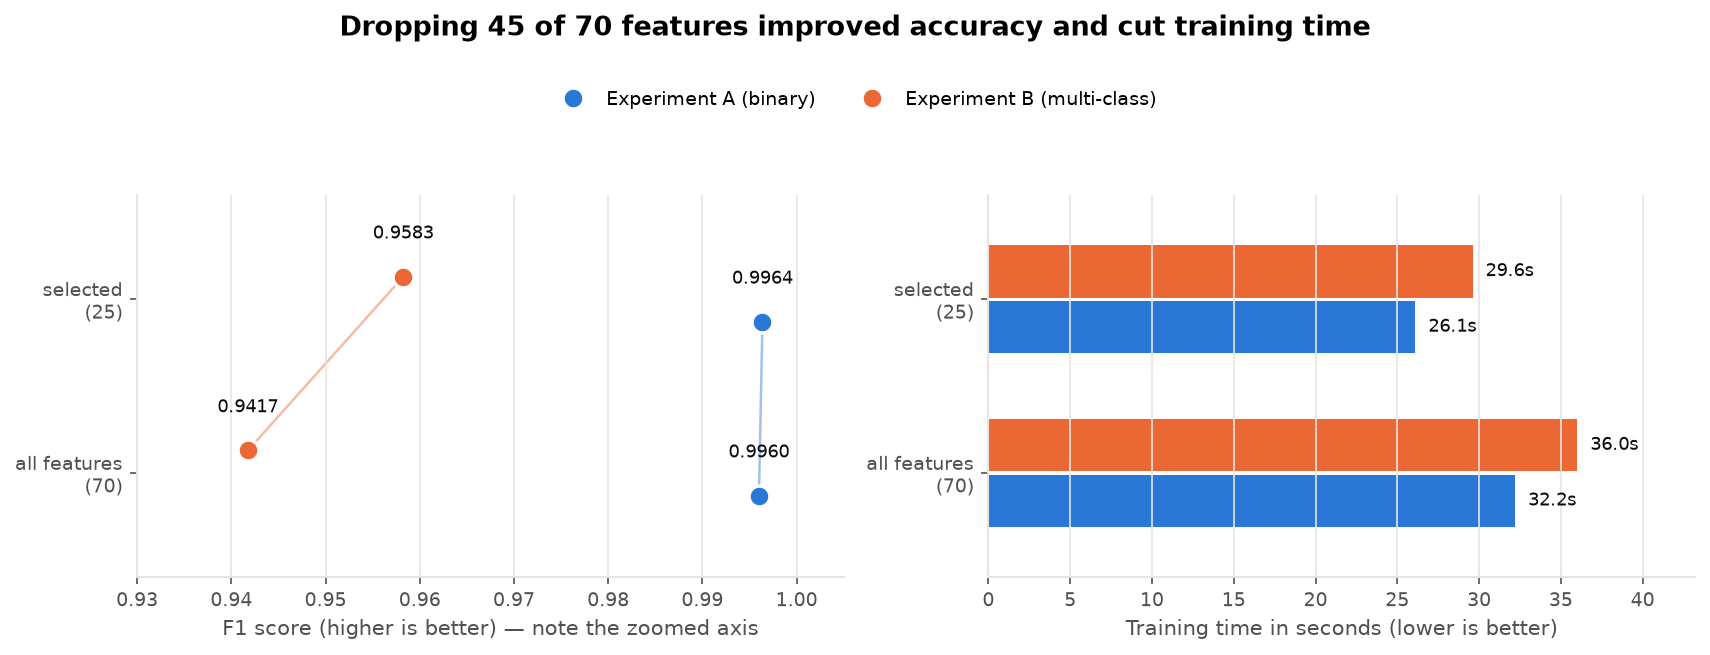

In [9]:
figure("07_feature_set_comparison.png")